# Sr2RuO4

Three-band effective model for the layered perovskite Sr$_2$RuO$_4$.

In [1]:
import sys
sys.path.append('../common')
from model import *
from analysis import load_all_results, compute_sigma, deviation_table, \
    plot_iw_comparison, plot_w_comparison, plot_static_obs_table, plot_chi_contour

Starting serial run at: 2026-04-16 19:01:45.205018


In [2]:
data = load_all_results()
block_lst = list(data[next(iter(data))]['G'].indices) if data else []

## 1. Single-Particle Green Function $G(i\omega_n)$


  G max-norm deviations:
                  alps_cthyb        cthyb  w2dyn_cthyb
     alps_cthyb                  5.01e-01     6.95e-01
          cthyb                               9.37e-01
    w2dyn_cthyb                                       


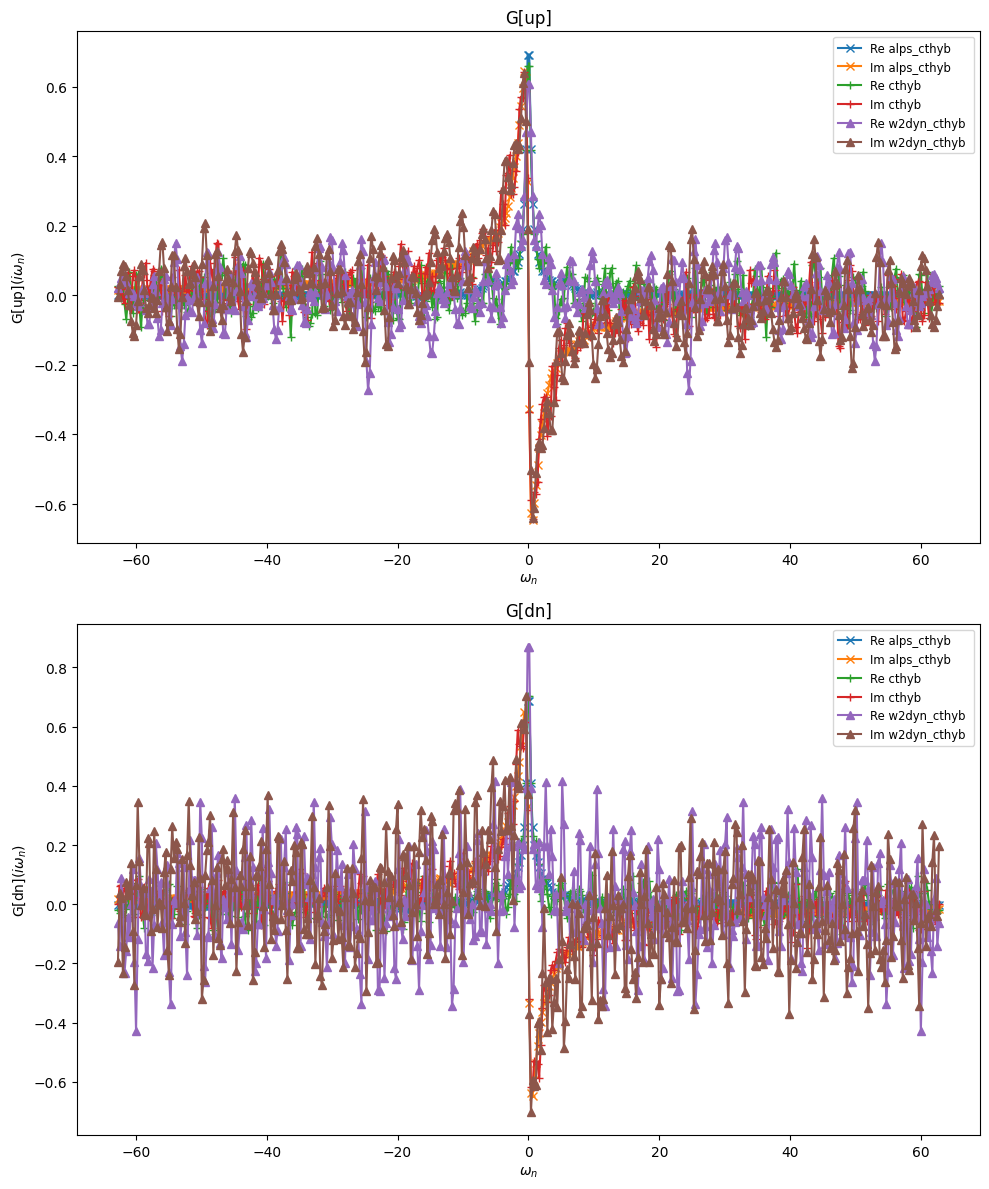

In [3]:
G_dict = {s: d['G'] for s, d in data.items() if 'G' in d}
if G_dict:
    plot_iw_comparison(G_dict, 'G', block_lst)
    deviation_table(G_dict, block_lst, label='G')

## 2. Self-Energy $\Sigma(i\omega_n)$


  Sigma max-norm deviations:
                  alps_cthyb        cthyb  w2dyn_cthyb
     alps_cthyb                  4.30e+02     4.39e+02
          cthyb                               4.19e+02
    w2dyn_cthyb                                       


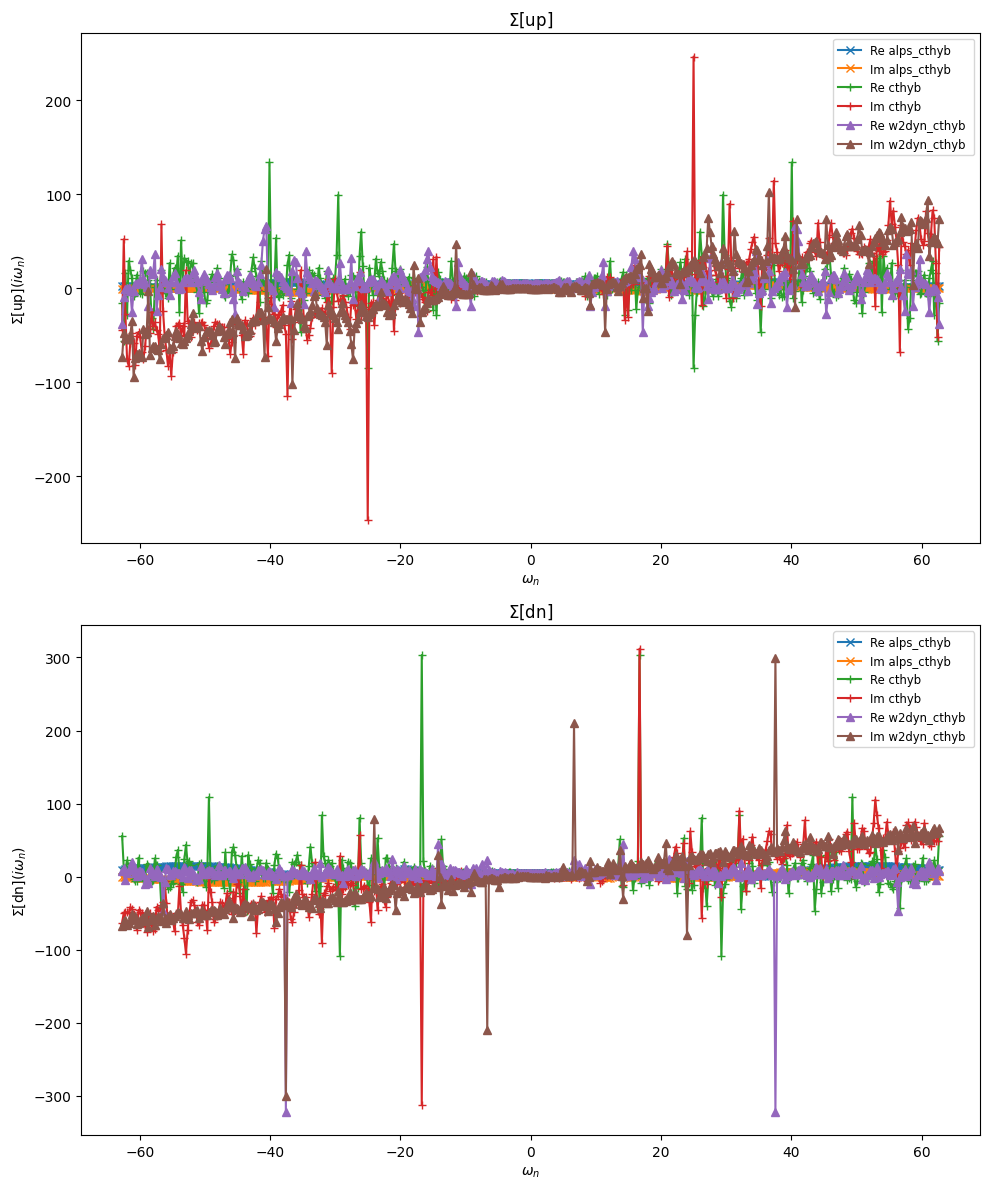

In [4]:
Sigma_dict = compute_sigma(data, G0_iw)
if Sigma_dict:
    plot_iw_comparison(Sigma_dict, r'$\Sigma$', block_lst)
    deviation_table(Sigma_dict, block_lst, label='Sigma')

## 3. Static Observables

In [5]:
plot_static_obs_table(data, 'density')
plot_static_obs_table(data, 'nn_ab')


  density:
    cthyb                 dn_0: 0.760926, dn_1: 0.622817, dn_2: 0.622764, up_0: 0.761330, up_1: 0.623070, up_2: 0.622878

  nn_ab:
    cthyb                 dn_0,dn_0: 0.760926, dn_0,dn_1: 0.463010, dn_0,dn_2: 0.462993, dn_0,up_0: 0.522256, dn_0,up_1: 0.423641, dn_0,up_2: 0.423446, dn_1,dn_0: 0.463010, dn_1,dn_1: 0.622817, dn_1,dn_2: 0.415851, dn_1,up_0: 0.423848, dn_1,up_1: 0.245888, dn_1,up_2: 0.330833, dn_2,dn_0: 0.462993, dn_2,dn_1: 0.415851, dn_2,dn_2: 0.622764, dn_2,up_0: 0.423772, dn_2,up_1: 0.331018, dn_2,up_2: 0.245642, up_0,dn_0: 0.522256, up_0,dn_1: 0.423848, up_0,dn_2: 0.423772, up_0,up_0: 0.761330, up_0,up_1: 0.463317, up_0,up_2: 0.463373, up_1,dn_0: 0.423641, up_1,dn_1: 0.245888, up_1,dn_2: 0.331018, up_1,up_0: 0.463317, up_1,up_1: 0.623070, up_1,up_2: 0.416326, up_2,dn_0: 0.423446, up_2,dn_1: 0.330833, up_2,dn_2: 0.245642, up_2,up_0: 0.463373, up_2,up_1: 0.416326, up_2,up_2: 0.622878


## 4. Real-Frequency Spectral Function $A(\omega)$

In [6]:
G_w_dict = {s: d['G_w'] for s, d in data.items() if 'G_w' in d}
if G_w_dict:
    plot_w_comparison(G_w_dict, 'G_w', block_lst, spectral=True)
else:
    print("No solver has real-frequency data.")

No solver has real-frequency data.


## 5. Three-Point Correlator $\chi_3$

In [7]:
for ch in ['d', 'm', 's', 't']:
    key = f'chi3_{ch}'
    chi3 = {s: d[key] for s, d in data.items() if key in d}
    if chi3:
        plot_chi_contour(chi3, ch)

## 6. Two-Particle Green Function $\chi_4$ / $G_{2c}$

In [8]:
for ch in ['d', 'm', 's', 't']:
    key = f'chi4_{ch}'
    chi4 = {s: d[key] for s, d in data.items() if key in d}
    if chi4:
        plot_chi_contour(chi4, ch)